**Project:** Data Mining II (2025/26)

**Group Number:** 12

**Members:**
- Beatriz Boura - 20250272
- Dinis Gaspar - 20221869
- Margarida Cruz - 20221929

**Introduction**


In this notebook, we'll look for insights, analyze data issues and find solutions, which we will then implement when developing our modeling pipeline.

**Table of contents**<a id='toc0_'></a>    
1. [Imports](#toc1_)    
2. [Analysis of Row uniqueness](#toc2_)    
3. [Exploratory Data Analysis](#toc3_)    
3.1. [Categorical columns](#toc3_1_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=true
	minLevel=1
	maxLevel=3
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Imports](#toc0_)

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from sklearn.feature_selection import SelectKBest, f_classif
from utils_EDA import (outlier_count_IQR, outlier_filter_IQR,
                            bar_charts_categorical, distribution_plot_grid,
                            cor_heatmap)

In [48]:
%cd ..
train = pd.read_csv('Datasets/donors_train.csv')
%cd EDA
train.head()

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\EDA


,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
0,61745,4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,...,17.50,NaN,0.000,2.0,0.154,0.0,2,T,NaN,1
1,112703,3.0,2.0,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1
2,166437,4.0,2.0,NaN,F,7.0,3.0,H,4.0,10.0,...,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0
3,170621,4.0,NaN,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0
4,44428,6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,...,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0


# 2. <a id='toc2_'></a>[Analysis of Row uniqueness](#toc0_)

We'll start by checking whether the training dataset contains any repeated rows. Firstly, checking the uniqueness of the donor identifier column "CONTROL_NUMBER" and then we'll check whether there are fully repeated feature combinations across different identifiers.

In [49]:
train['CONTROL_NUMBER'].duplicated().sum()

np.int64(0)

We can conclude that there are no repeated unique identifiers of each donor, this means we can and will use the CONTROL_NUMBER variable as the index for our Dataframe.

In [50]:
train.set_index('CONTROL_NUMBER', inplace=True)

In [51]:
train.duplicated().sum()

np.int64(0)

From the above cell, we can be certain that all donor profiles are unique and not repeated. Now, we will start to look deeper at the actual data, with regards to column-specific issues and insights. 

# 3. <a id='toc3_'></a>[Exploratory Data Analysis](#toc0_)

| Attribute | Description | Variable Type |
| :--- | :--- | :--- |
| **CONTROL_NUMBER** | Unique identifier of each possible donor | ID |
| **DONOR_AGE** | Age as of last year's mail solicitation | Numerical |
| **URBANICITY** | Nature of the donor's location U= Urban C= City T = Town R = Rural S=Suburban | Categorical |
| **SES** | Code assigning each individual to one of 5 demographic profiles based on socioeconomic characteristics | Categorical (Ordinal) |
| **HOME_OWNER** | H if individual is a Homeowner, U if it is Unknown | Categorical |
| **DONOR_GENDER** | Gender of individual | Categorical |
| **INCOME_GROUP** | Code assigning each individual to one of 7 income group levels | Categorical (Ordinal) |
| **WEALTH_RATING** | Code assigning each individual to one of 10 wealth rating groups | Categorical (Ordinal) |
| **MEDIAN_HOME_VALUE** | Individuals' median home value in \$100's | Numerical |
| **MEDIAN_HOUSEHOLD_INCOME** | Individuals' median household income in \$100's | Numerical |
| **PCT_OWNER_OCCUPIED** | Percent of owner-occupied housing near where person lives | Numerical |
| **PER_CAPITA_INCOME** | Per Capita Income of neighborhood in which person lives | Numerical |
| **PCT_ATTRIBUTE1** | Percent of residents in person's neighborhood that are male and active military | Numerical |
| **PCT_ATTRIBUTE2** | Percent of residents in person's neighborhood that are male and veterans | Numerical |
| **PCT_ATTRIBUTE3** | Percent of residents in person's neighborhood that are Vietnam veterans | Numerical |
| **PCT_ATTRIBUTE4** | Percent of residents in person's neighborhood that are WW2 veterans | Numerical |
| **PEP_STAR** | If person achieved STAR donor status, given to individuals who have given to 3 consecutive campaigns. | Categorical (Binary) |
| **RECENT_STAR_STATUS** | If achieved STAR within last 4 years. | Categorical (Binary) |
| **RECENCY_STATUS_96NK** | Donor status: A (active - made their first donation more than 12 months ago and has made a donation in the last 12 months.); E (inactive - made a donation 25+ months ago.); F (first time - made their first donation in the last 6 months and has made just one donation.); L (lapsing - made their last donation between 13-24 months ago); N (new - made their first donation in the last 12 months and is not a First time donor); S (star donor) | Categorical |
| **FREQUENCY_STATUS_97NK** | Number of times donated in last period (The period of recency for all groups except L and E is the last 12 months. For L it is 13-24 months ago, and for E it is 25-36 months ago). | Numerical |
| **RECENT_RESPONSE_PROP** | Proportion of responses to the individual to the number of (card or other) solicitations from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_GIFT_AMT** | Average donation from the individual to the charitable organization in the last four years. | Numerical |
| **RECENT_CARD_RESPONSE_PROP** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_CARD_GIFT_AMT** | Average donation from the individual in response to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_RESPONSE_COUNT** | Number of times the individual has responded to a promotion (card or other) from the charitable organization in the last four years | Numerical |
| **RECENT_CARD_RESPONSE_COUNT** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years. | Numerical |
| **MONTHS_SINCE_LAST_PROM_RESP** | Number of months since the individual has responded to a promotion by the charitable organization | Numerical |
| **LIFETIME_CARD_PROM** | Total number of card promotions sent to the individual by the charitable organization | Numerical |
| **LIFETIME_PROM** | Total number of promotions (card or other) sent to the individual by the charitable organization | Numerical |
| **LIFETIME_GIFT_AMOUNT** | Total lifetime donation amount from the individual to the charitable organization | Numerical |
| **LIFETIME_GIFT_COUNT** | Total number of donations from the individual to the charitable organization | Numerical |
| **LIFETIME_MAX_GIFT_AMT** | Maximum donation amount from individual | Numerical |
| **LIFETIME_MIN_GIFT_AMT** | Minimum donation amount from individual | Numerical |
| **LAST_GIFT_AMT** | Amount donated in the individuals most recent donation | Numerical |
| **CARD_PROM_12** | Number of card promotions sent to the individual by the charitable organization in the last 12 months | Numerical |
| **NUMBER_PROM_12** | Number of promotions (card or other) sent to the individual by the charitable organization in the last 12 months | Numerical |
| **MONTHS_SINCE_LAST_GIFT** | Number of months since the most recent donation from the individual to the charitable organization | Numerical |
| **MONTHS_SINCE_FIRST_GIFT** | Number of months since the first donation from the individual to the charitable organization | Numerical |
| **FILE_CARD_GIFT** | Lifetime average donation from the individual in response to all card solicitations from the charitable organization | Numerical |
| **CHILDREN** | Number of children the individual has | Numerical |
| **TARGET_B** | Whether person has donated in the last year's campaign or not (1 or 0 respectively) | Target (Birnary) |

In the table above, we have all of the variables and variable decriptions for our data and a variable type (numerical or categorical) assigned based on the descriptions. These assigments allow us to tailor exploration techniques to extract the most relevant insights for both types of variables.

In [52]:
# These lists will allow us to filter the dataset by the relevant datatype for
# each type of analysis

# Numerical Variables
num_cols = [
    "DONOR_AGE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "MONTHS_SINCE_LAST_PROM_RESP",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_CARD_GIFT",
    "CHILDREN"
]

# Categorical Variables
cat_cols = [
    "URBANICITY",
    "SES",
    "HOME_OWNER",
    "DONOR_GENDER",
    "INCOME_GROUP",
    "WEALTH_RATING",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "RECENCY_STATUS_96NK",
]

As this is a binary classification problem, we'll start by checking whether the target variable is balanced.

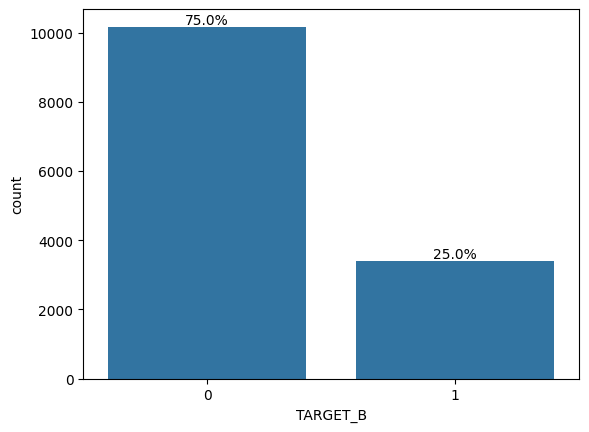

In [53]:
# Create the plot
ax = sns.countplot(data=train, x='TARGET_B')

# Calculate percentages
total = len(train['TARGET_B'])
labels = [f'{(v.get_height()/total)*100:.1f}%' for v in ax.patches]

# Add the percentage labels
ax.bar_label(ax.containers[0], labels=labels)

plt.show()

It's now clear that we are dealing with an unbalanced target, this means that relevant precautions must be considered during modeling to ensure that the model can correctly identify cases where donor donated and didn't donate correctly. These precautions include using the appropriate metrics, such as F1 score which is the metric we will use since it's also (due to this imbalance) the metric used in the kaggle competitons, but also techniques such as applying class wieghts in models that support it.

## 3.1. <a id='toc3_1_'></a>[Categorical columns](#toc0_)

Now, we're gonna look at our categorical columns.


## Value consistency evaluation

As a first step, we'll check the all of unique values for each of our variables to look for inconsistencies our unexpected values.

In [54]:
for col in cat_cols:
    print(f'{col} : {train[col].unique().tolist()}')

URBANICITY : ['T', 'R', 'U', 'C', nan, 'S', '?']
SES : ['2', '3', '1', '4', nan, '?']
HOME_OWNER : ['H', 'U', nan]
DONOR_GENDER : ['M', 'F', 'U', nan]
INCOME_GROUP : [5.0, nan, 4.0, 6.0, 3.0, 2.0, 1.0, 7.0, 9.503279718784624, -1.737976712944631]
WEALTH_RATING : [nan, 4.0, 1.0, 5.0, 2.0, 0.0, 7.0, 6.0, 9.0, 8.0, 3.0, 13.451898003766887, -3.752821118381721]
PEP_STAR : [0.0, 1.0, nan, -0.5298718146873891, 2.004584679238949]
RECENT_STAR_STATUS : [0.0, 1.0, 6.0, nan, -7.809472848272476, 10.0, 3.0, 7.0, 5.0, 18.0, 12.0, 4.0, 11.0, 16.0, 15.0, 19.0, 8.587873099593457, 8.0, 13.0, 2.0, 14.0, 21.0, 9.0, 17.0, 22.0, 20.0]
RECENCY_STATUS_96NK : ['A', 'N', 'S', 'E', 'F', nan, 'L']



There are some clear takeaways from the unique values for our categorical columns:
+ Our analysis of SES, WEALTH_RATING and INCOME_GROUP as ordinal variables seems to be confirmed as these are already numerically encoded in an ordinal manner. Additionally the nature of these columns as ratings based on socioeconomic characteristics also fit the logic of an ordinal categorical variable.
+ Additionally the variables that use numerical encondings (ordinal and binary) all have a set of values which are either negative, stragely long decimals or both. These values are probably erroneous and likely result from the compilation of the data from the original set of donations. We'll look into this with our numerical variables as well.
+ There are two variables (URBANICITY, SES) with a "?" value, which we're going to consider missing values.
+ The HOME_OWNER variable as expected from the variable description is in reality a binary flag variable since it only contains H for homeowner, U for unknown, which is essentially a missing value and actual missing values. In our model pipelines
we will transform this into a binary variable where H will be 1 and U or NaN will be 0.
+ The DONOR_GENDER variable contains 3 categories, M and F for Male and Female and U category which likely represents unspecified. We're gonna consider it a valid category as it's likely a conscious decision of the donor not to share the information rather than a value which wasn't captured.
+ The description of the SES variable mentions 5 categories, but only 4 levels appear in the data.
+ The RECENT_STAR_STATUS feature is described as an indicator of whether the donor has reached STAR status within the last 4 years, and thus should be a binary variable, yet it contains seemingly correct values up to 22. This could likely be due to incorrect values or an outdated variable description for a case where the variable now stores a count of times the donor achieved STAR status and not just whether or not the donor achieved it. <p>

## Distributions and target proportions

Below, the distributions of categories within each variable as well as the proportion of the target within each category will be evaluated.

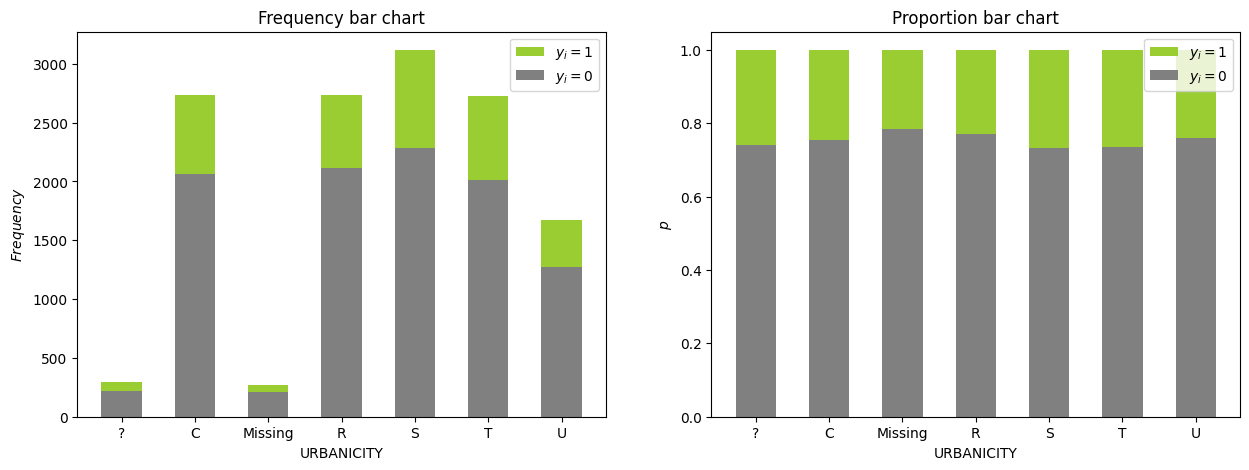

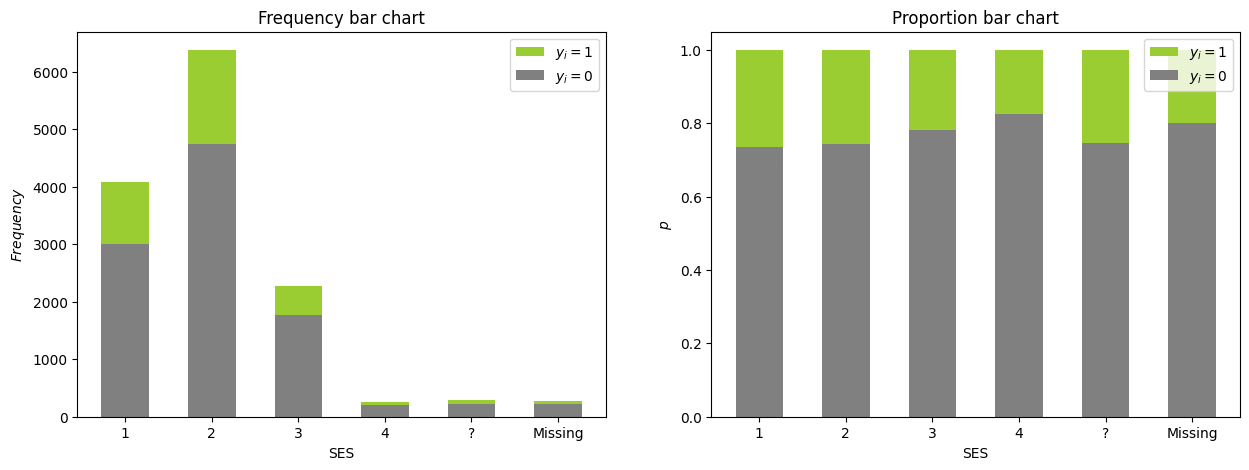

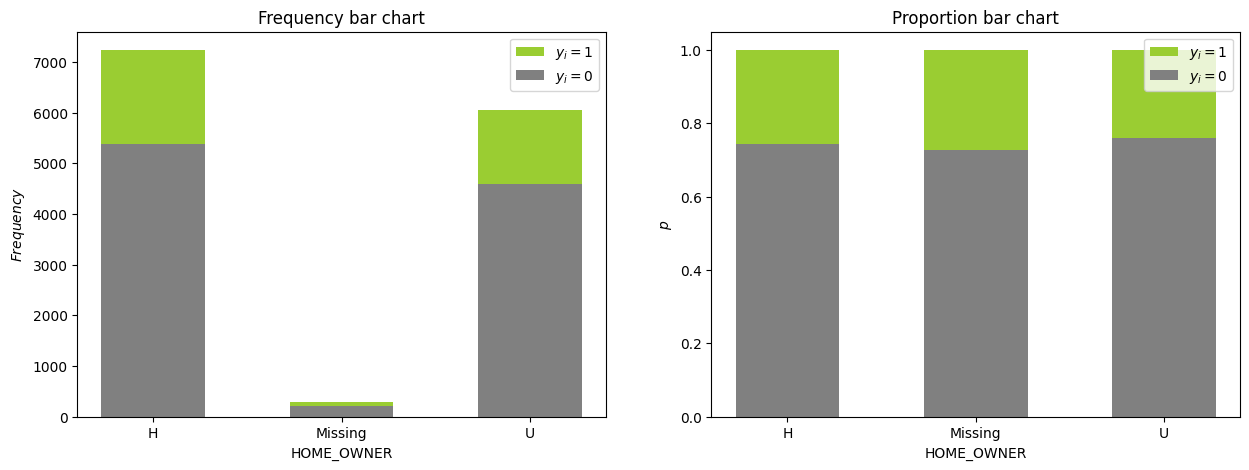

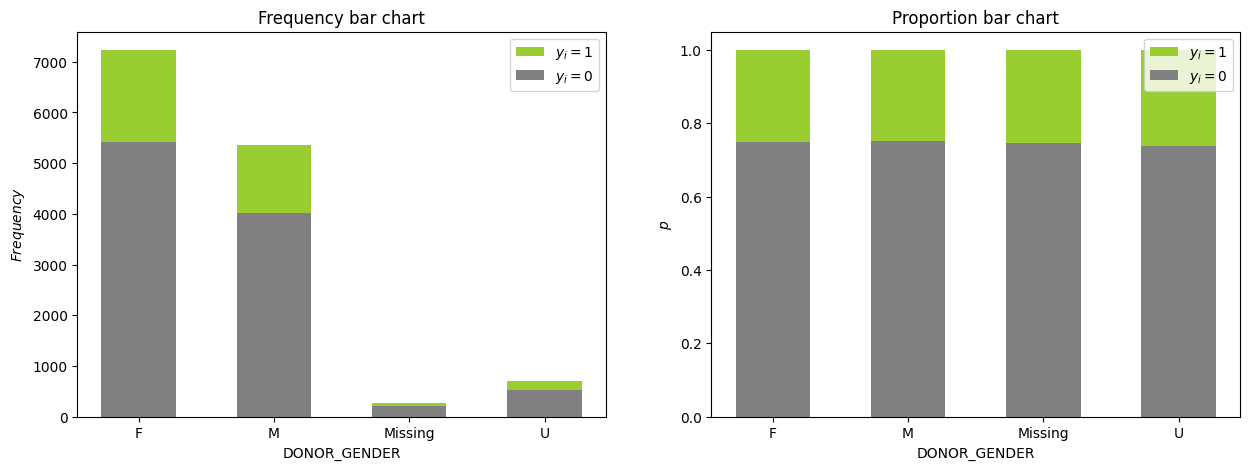

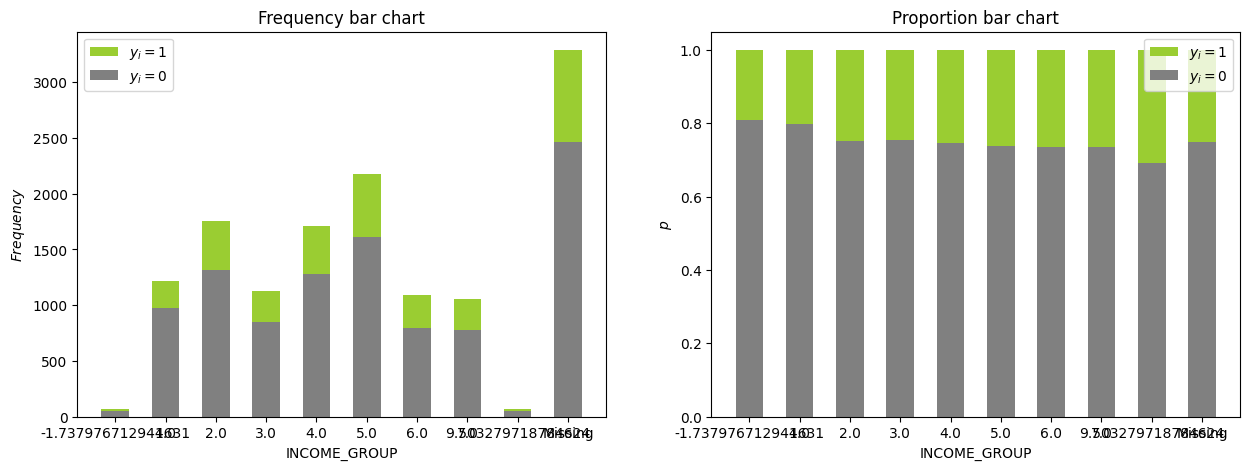

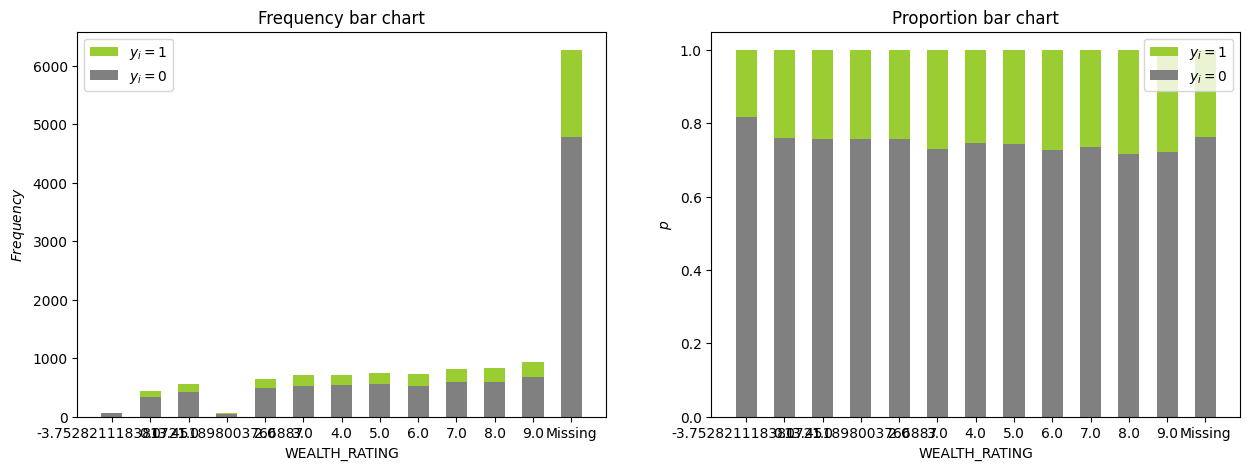

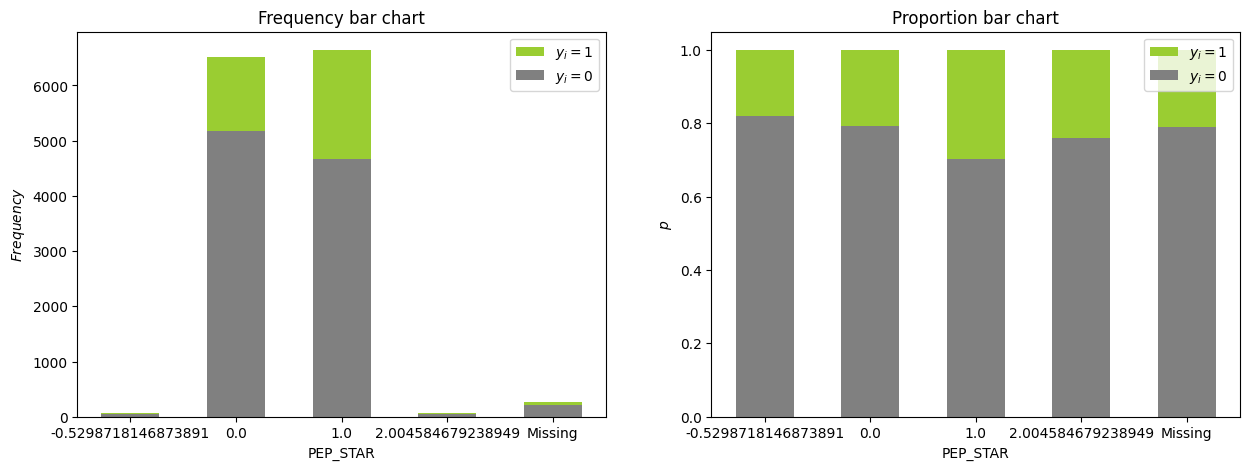

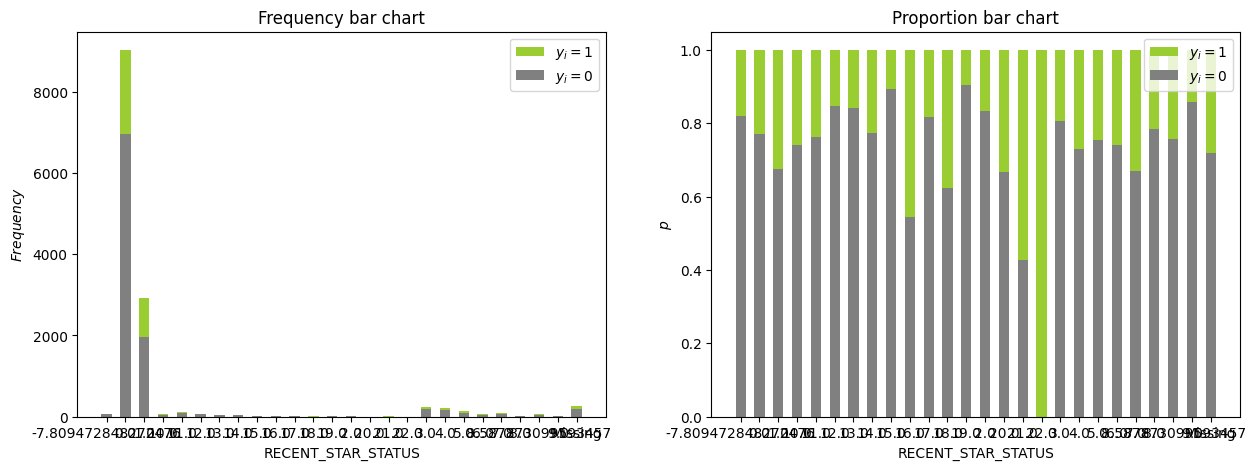

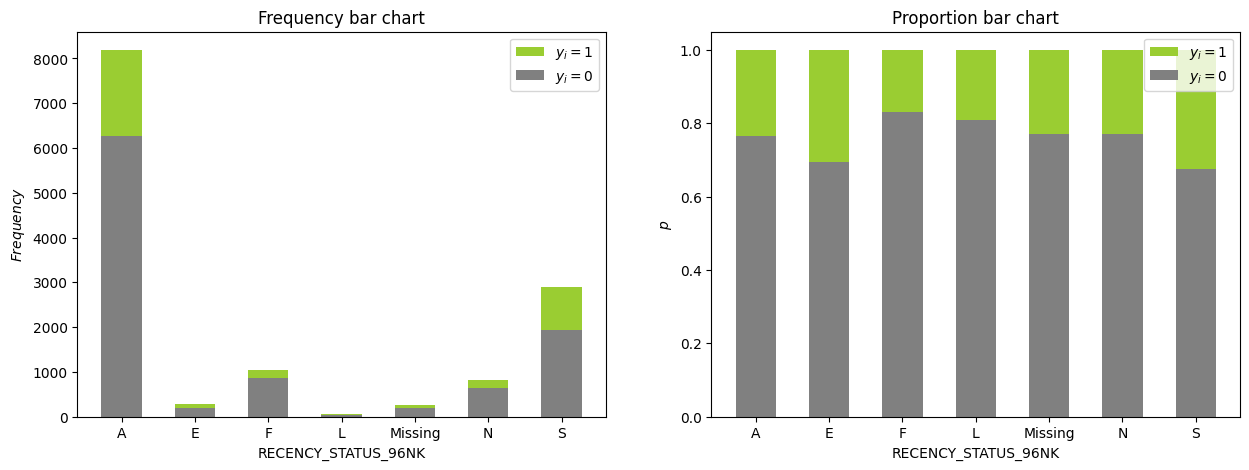

In [55]:
bar_charts_categorical(train.astype({col : 'str' for col in cat_cols}).fillna('Missing'), cat_cols, 'TARGET_B')

Looking at plots above there are a few relevant insights:
+ The distribution of the URBANICITY variable is not uniform with S for Suburban being slightly more common and U for Urban less common, the other three categories are found in similar quantities in the data. There are very small variations in the proportion of the target between categories even comparing to missing values, they're all between 0.7 and 0.8, around the overall proportion of the targe in the data.
+ Within the SES variable, level 2 is by far the most common, followed by level 1 and then level 3. Level 4 is quite uncommon. Again, there are small differences between the proportion of the target across categories, but they're all once again very close to the global value.
+ For the HOME_OWNER variable H for homeowner is slightly more common than Unknown, but the target proportion across both (and missing values) is essentially identical. This validates our plan to transform this into a binary variable from above.
+ The DONOR_GENDER variable tells us that there are more women in our data (F) than men (M) and only a relatively small amount of donors chose not to specify their gender (U). The target proportions across the three categories and missing values are essentially identical. Given the small amount of categories, the identical target distribution and the fact that ordinally enconding gender is not very logical, one-hot encoding the gender is the best option.
+ The INCOME_GROUP has a large amount of missing values as well as the strage decimal values mentioned above. Within the acceptable values there is some discrepencies in terms of counts with level 5 being the most common followed by 2 and 4 with similar presence and finally the 4 remaining levels which also appear in similar amounts. Once again, there are some fluctuations of the target proportion across categories, missing values and strange decimals, but these are small and around the global proportion of the dataset.
+ The WEALTH_RATING contains a very large amount of missing values, almost 50% and also the strange decimal values. The distribution among the valid categories of the variable is not uniform but it is quite stable. The target proportion across all of the values is once again very similar with some variation.
+ Slightly more donors  have reached STAR status comapring to those that haven't (STAR_STATUS), there are also missing values and more decimal values. Interestingly, the proportion of the target is a bit lower among those who have never achieved STAR status.  
+ As mentioned above the RECENT_STAR_STATUS contains missing values and a lot of different unexpected values, although in reality these are far less common than the expected 0 and 1 values, within which the number of donors who haven't achieved STAR status in the last 4 years is far more common. Between these two, much like the STAR_STATUS variable the proportion of the target is lower among those who have achieved it. Looking at the proportions for other values isn't very relevant as they are so uncommon that the proportion will not be a trustworthy indicator.
+ Finally, from the RECENCY_STATUS_96NK variable we can conclude that the large majority of donors are active (A) and a good amount are STAR donors (S), new (N) and first time (F) donors appear in smaller amounts and Lapsing (L) or Inactive (E) donor are quite rare (less common than missing values). Looking at the target proportions there are differences across classes, interestingly donors without a status (Missing) and Active donors share extremely similar proportions, thus indicating that using the mode (A - Active) to impute them is probably a safe idea. Contrarily to expectations, Lapsing and Inactive donors who receive this classification for not donationg for 12+ and 24+ months respectively actually have registered instances of donating to last year's camapaign, this likely indicates that the Recency Status assessment was performed before that campaign and the donors were re-engaged with the CSA in that particular campaign. 

## Statistical test - Chi-square independence test

In this section, we're gonna preview the 2 statistical tests, Chi-square independence test and ANOVA test, we will use within our pipeline for categorical feature selection. This is purely informational since we're using crossvalidation for our modeling stage and distributions will change from fold to fold, this process must be included within the pipeline and no definitive conclusions can be taken from the analysis on the full training dataset. Some insights can still be extracted however. <p>
For both tests, we're going to consider a 5% significance level as that is the conventionally accepted value.

In [56]:
from scipy.stats import chi2_contingency
def chi2_TestIndependence(data, target, variables, alpha=0.05):
    '''
    This function will follow the steps of chi-square to check if an
    independent variable is an important predictor towards a dependent
    variable. It receives the full dataset, the name of the dependent
    variable and a list of predictors to test as well as the signifcance level
    to be used for the test. It returns a dataframe containing a Keep or
    Discard verdict for each feature

    Parameters:
        ----------
         - data (pd.DataFrame): The DataFrame containing the data.
         - target (str): The name of the dependent variable
         - variables (list): The column names of the variables to be evaluated.
         - alpha (float): The significance level to consider for the chi-square
         test

    Returns:
        ----------
        A dataframe containing the results of the test
    '''
    chi2_check = []
    # Get the X and y datasets for the test
    X_chi = data.drop(target, axis=1)
    y = data[target]
    res = pd.DataFrame(columns=['chi2'])
    for var in variables:
        # If p-value < alpha, reject H0 (similarity across groups)
        # and keep feature
        if chi2_contingency(pd.crosstab(y, X_chi[var]))[1] < alpha:
            res.loc[var, 'chi2'] = 'Keep'
        else:
            res.loc[var, 'chi2'] = 'Discard'

    return res

In [57]:
chi2_TestIndependence(train, 'TARGET_B', cat_cols)

,chi2
URBANICITY,Keep
SES,Keep
HOME_OWNER,Keep
DONOR_GENDER,Discard
INCOME_GROUP,Keep
WEALTH_RATING,Discard
PEP_STAR,Keep
RECENT_STAR_STATUS,Keep
RECENCY_STATUS_96NK,Keep
